# Modelos de regresión lineal regularizados

La regularización es una estrategia para reducir la complejidad de los modelos a través del control del tamaño de los coeficientes. Con este estrategia se busca reducir la **varianza** del modelo, sin aumentar su **sesgo**.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Vamos a trabajar con un dataset sintético con una solo 2 variables, una de entrada, y otra de salida.

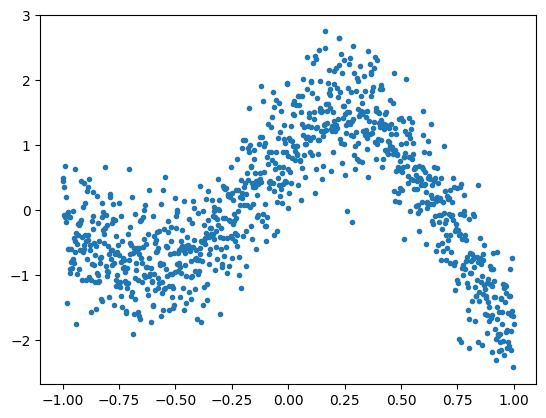

In [ ]:
X = np.linspace(-1, 1, 1000)
ruido = np.random.normal(0, 0.5, 1000)
y = np.sin(4*X) + np.cos(3*X) + ruido
X = X.reshape(-1,1)
plt.plot(X,y, '.');

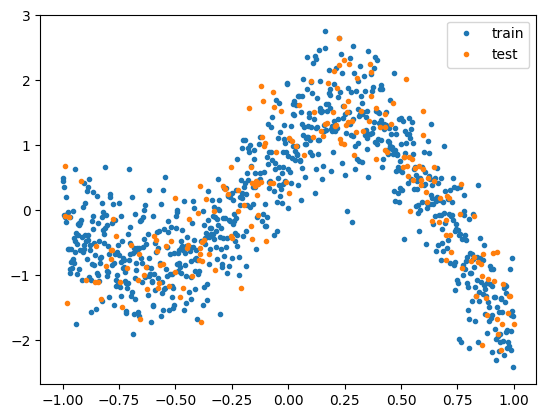

In [ ]:
from sklearn.model_selection import train_test_split

X = X

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=72, train_size=0.8)

plt.plot(X_train, y_train, '.', label ='train')
plt.plot(X_test, y_test, '.', label ='test')
plt.legend();

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error

pipeline = make_pipeline(
    PolynomialFeatures(include_bias=False, degree=10),
    LinearRegression()
    )

pipeline.fit(X_train, y_train)

print('Train score: ', root_mean_squared_error(y_train, pipeline.predict(X_train)))
print('Test score: ', root_mean_squared_error(y_test, pipeline.predict(X_test)))


Train score:  0.5040484368362449
Test score:  0.4994690761012698


Los coeficientes de este modelo son:

In [ ]:
print(f'Las pendientes de este modelo son: {pipeline.named_steps['linearregression'].coef_}')
print(f'El intercepto de este modelo es: {pipeline.named_steps['linearregression'].intercept_}')

Las pendientes de este modelo son: [  4.0394297   -3.51764131 -12.33603915  -6.40137225  13.91376834
  34.280804    -9.40608181 -48.98122669   2.99991333  22.84178758]
El intercepto de este modelo es: 0.9640290716054999


# Modelo Ridge

Ahora vamos a aplicar modelos regularizados para ver si obtenemos un mejor desempeño.

Estos modelos tienen un hiperparámetro llamado $\lambda$ con el que se controla cuanto reducir la complejidad. $\lambda$ puede tomar valores en el rango $[0, \infty)$, y mientras más grande sea más reduce el tamaño de los coeficientes y más reduce la complejidad del modelo.

En Scikit Learn estos modelos están implementados en las clases `Ridge` y `Lasso`, y el factor de regularización se llama alpha.

In [ ]:
from sklearn.linear_model import Ridge

pipeline = make_pipeline(
    PolynomialFeatures(include_bias=False, degree=10),
    Ridge(solver='saga',max_iter=10000)
)

pipeline.fit(X_train, y_train)

print('Train RMSE: ', root_mean_squared_error(y_train, pipeline.predict(X_train)))
print('Test RMSE: ', root_mean_squared_error(y_test, pipeline.predict(X_test)))

Train RMSE:  0.5261504394368582
Test RMSE:  0.5141575541199883


Vamos a evaluar este modelo por validación cruzada para tener una aproximación más realista de su verdadero **error de generalización**. Vamos a probar nuestro modelo con diferentes valores de $\lambda$.

In [ ]:
from sklearn.model_selection import cross_val_score

alphas = [0, 0.001, 0.01, 0.1, 1, 10, 100, 1000]

for alpha in alphas:
  model = pipeline.set_params(ridge__alpha=alpha)
  score = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
  print('Alpha: ', alpha)
  print('Validation RMSE:', -score.mean())
  print('Pesos: ', model.named_steps['ridge'].coef_)
  print()

Alpha:  0
Validation RMSE: 0.5111854195968493
Pesos:  [ 2.61425909 -2.77672156 -3.69092444 -0.07922862 -1.34855856  0.39539217
  0.33730119  0.37253075  1.24353685  0.29056154]

Alpha:  0.001
Validation RMSE: 0.5111362365950936
Pesos:  [ 2.61425909 -2.77672156 -3.69092444 -0.07922862 -1.34855856  0.39539217
  0.33730119  0.37253075  1.24353685  0.29056154]

Alpha:  0.01
Validation RMSE: 0.5113347427626291
Pesos:  [ 2.61425909 -2.77672156 -3.69092444 -0.07922862 -1.34855856  0.39539217
  0.33730119  0.37253075  1.24353685  0.29056154]

Alpha:  0.1
Validation RMSE: 0.5150207629881024
Pesos:  [ 2.61425909 -2.77672156 -3.69092444 -0.07922862 -1.34855856  0.39539217
  0.33730119  0.37253075  1.24353685  0.29056154]

Alpha:  1
Validation RMSE: 0.5341059103314443
Pesos:  [ 2.61425909 -2.77672156 -3.69092444 -0.07922862 -1.34855856  0.39539217
  0.33730119  0.37253075  1.24353685  0.29056154]

Alpha:  10
Validation RMSE: 0.628084534001876
Pesos:  [ 2.61425909 -2.77672156 -3.69092444 -0.0792286

Se observa que el error de validación baja cuando se incrementa el valor de $\lambda$, pero hasta cierto punto, porque después vuelve a subir.

Por otra parte, el tamaño de los coeficientes si baja a medida que se aumenta el valor de $\lambda$.

# Sintonización de hiperparámetros

Dado que $\lambda$ puede tomar un rango muy amplio de valores (desde 0 hasta $\infty$), encontrar el valor óptimo con el que se obtenga el **menor error de validación** es un gran desafío.

Lo que se puede hacer es probar con un gran número de valores, y de estos valores seleccionar el que de mejores resultados. Este proceso se conoce como **sintonización de hiperparámetros**.

Otro problema aquí es que para saber que valor del hiperparámetro da mejores resultados se debería evaluar con datos diferentes a los datos con los que se entrena el modelo, pero estos a la vez deberían ser diferentes a los datos con los que se evalúa el modelo ya ajustado y con los hiperparámetros seleccionados. Esto implica que de nuestro dataset debemos sacar 3 subconjuntos:
- Un subconjunto para entrenar el modelo con cada hiperparámetro.
- Un subconjunto para evaluar el modelo ajustado con cada hiperparámetro.
- Un subconjunto para evaluar el modelo ajustado con el hiperparámetro ya seleccionado.

Estos 3 subconjuntos se conocen respectivamente como conjunto de datos de **entrenamiento**, **validación** y **prueba**. A esto hay que añadir que lo ideal sería entrenar y validar cada hiperparámetro con varios conjuntos de datos, para evitar sesgo y saber que tanta varianza tiene.

Dado todo lo anterior, habría que hacer una primera partición de los datos, antes de hacer cualquier procesamiento a la matriz de características y de entrenar los modelos. Como ya sabemos, esto en `Scikit Learn` se puede hacer con el método `train_test_split`. De esta manera nos quedaría un subconjunto de datos para entrenar el modelo y sintonizar los hiperparámetros, que llamaremos por ahora **dataset de entrenamiento**, y otro para evaluar los modelos con los hiperparámetros ya sintonizados y ajustados, que llamaremos **dataset de prueba**.



Con el dataset de prueba no se hará nada hasta el final.

Ahora, la obtención de los subconjuntos de entrenamiento y validación para sintonizar hiperparámetros puede hacerse por validación cruzada. Aunque el método `cross_val_score` nos serviría, existen en `Scikit Learn` métodos especializados para hacer sintonización de hiperparámetros por validación cruzada, uno de los cuales es `GridSearchCV`.

In [ ]:
from sklearn.model_selection import GridSearchCV

alpha = np.logspace(-4, 4, 50)

grid = dict(ridge__alpha = alpha)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=grid,
    scoring='neg_root_mean_squared_error',
    )

grid_search.fit(X_train, y_train)

print(f'Mejor RMSE obtenido fue {-grid_search.best_score_:.3} con lambda de {grid_search.best_params_}.')

Mejor RMSE obtenido fue 0.511 con lambda de {'ridge__alpha': np.float64(0.0029470517025518097)}.


`GridSearchCV`, y métodos similares, tienen una ventaja adicional sobre hacer CV de manera manual para sintonizar hiperparámetros, y es que **entregan el mejor modelo ya sintonizado y entrenado**. El mejor modelo se obtiene usando el atributo **best_estimator_**.

Con este, ya es posible hacer predicciones y evaluar el modelo con datos de prueba.

In [ ]:
best_model = grid_search.best_estimator_

print('Train RMSE: ', root_mean_squared_error(y_train, best_model.predict(X_train)))
print('Test RMSE: ', root_mean_squared_error(y_test, best_model.predict(X_test)))

Train RMSE:  0.5049979386911831
Test RMSE:  0.4982343060330989


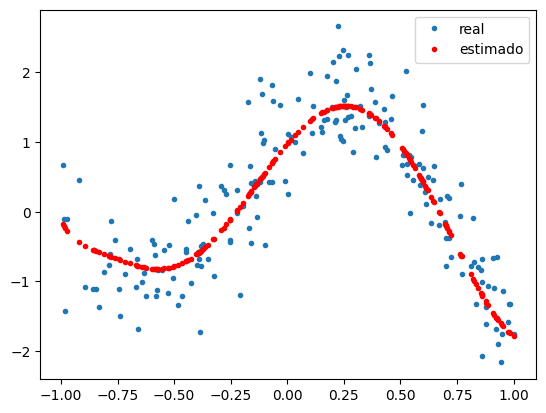

In [ ]:
y_est = best_model.predict(X_test)
plt.plot(X_test, y_test, '.', label ='real')
plt.plot(X_test, y_est, '.r', label = 'estimado')
plt.legend();

Vemos que este modelo efectivamente tiene menor error. Los coeficientes de este modelo son:

In [ ]:
print(f'Las pendientes de este modelo son: {best_model.named_steps['ridge'].coef_}')
print(f'El intercepto de este modelo es: {best_model.named_steps['ridge'].intercept_}')

Las pendientes de este modelo son: [ 3.82261671 -4.53436626 -9.65212448  4.36836363  4.52663092 -1.58693802
  3.02926787 -2.52194647 -2.55218439  2.34451537]
El intercepto de este modelo es: 0.9744608822510759


En este caso, la disminución del tamaño de los coeficientes fue mínima, porque el mejor valor encontrado para $\lambda$ fue pequeño. Sin embargo, vemos que esto fue suficiente para mejorar el modelo.

Es una buena práctica reportar los coeficientes asociados a las características. Cuando se usa un método de preprocesamiento que genera nuevas características, como en este caso con el generador de características polinómicas, los nombres de estas caracterísitcas se pueden obtener con el método `get_feature_names_out`.

In [ ]:
coeficientes = pd.DataFrame(
    best_model.named_steps['ridge'].coef_,
    index=best_model.named_steps['polynomialfeatures'].get_feature_names_out(),
    columns=['coef']
    )

coeficientes.loc['intercept'] = best_model.named_steps['ridge'].intercept_
coeficientes.sort_values(by='coef', ascending=False)

,coef
x0^5,4.526631
x0^4,4.368364
x0,3.822617
x0^7,3.029268
x0^10,2.344515
intercept,0.974461
x0^6,-1.586938
x0^8,-2.521946
x0^9,-2.552184
x0^2,-4.534366


# Ejercicio

Cargar el archivo 'auto-mpg.data', póngale nombre a las columnas de acuerdo a lo indicado en el archivo 'auto-mpg.names'.

Configure como índice la variable 'car_name'.

Haga un modelo de regresión Ridge que prediga la variable 'mpg' usando todas las demás variables disponibles como predictoras. Para esto haga una partición de los datos en subconjuntos de entrenamiento y prueba en una proporciòn 70/30, usando random_state=1.

Reporte el mejor valor de $\lambda$ encontrado, el RMSE de entrenamiento y el de prueba con este valor, el intercepto y los pesos del modelo.